# Lab Task 4: Linear Regression and Optimization
## Setup: Import Required Libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

## Setup: Create Dataset

In [21]:
import numpy as np

np.random.seed(42)

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # actual relation + noise


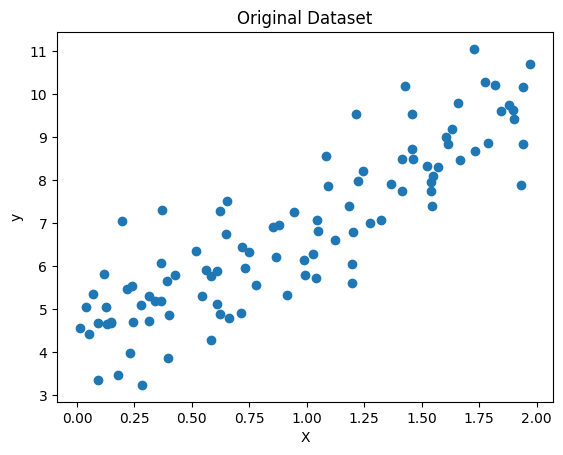

In [22]:
# plot the dataset
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Original Dataset")
plt.show()


## TASK 1: Linear Regression from Scratch (Normal Equation)

In [23]:
X_b = np.c_[np.ones((100, 1)), X]
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
y_pred_manual = X_b @ theta_best


In [24]:
# extract weights and bias from theta vector
b = theta_best[0][0]
w = theta_best[1][0]


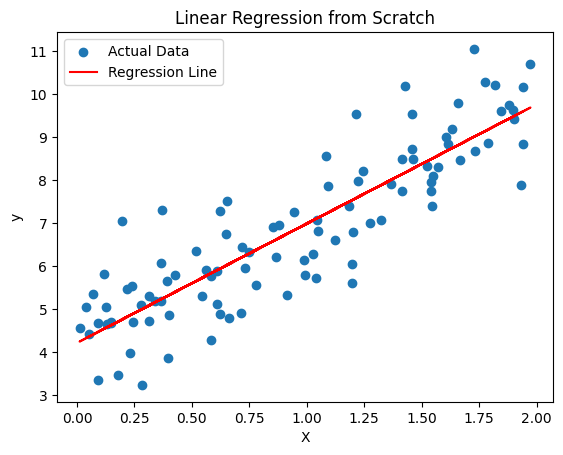

In [25]:
# make the Predictions fro scratch
y_pred = X_b @ theta_best

# now plot the results
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, color="red", label="Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression from Scratch")
plt.legend()
plt.show()


### Task 1 Result: Final Equation

In [26]:
print(f"Final Equation: y = {w:.2f}x + {b:.2f}")


Final Equation: y = 2.77x + 4.22


## TASK 2: Linear Regression Using Standard Library

In [27]:
lib_model = LinearRegression()
lib_model.fit(X, y)

y_pred_lib = lib_model.predict(X)
w_lib = lib_model.coef_[0][0]
b_lib = lib_model.intercept_[0]

print(f"Library Equation: y = {w_lib:.2f}x + {b_lib:.2f}")

Library Equation: y = 2.77x + 4.22


## TASK 3: Compare Scratch vs Library (MSE and R2)

In [28]:
mse_scratch = mean_squared_error(y, y_pred_manual)
r2_scratch = r2_score(y, y_pred_manual)

mse_lib = mean_squared_error(y, y_pred_lib)
r2_lib = r2_score(y, y_pred_lib)

print("Scratch (Normal Equation)")
print(f"MSE: {mse_scratch:.4f}")
print(f"R2 : {r2_scratch:.4f}\n")

print("Library (scikit-learn)")
print(f"MSE: {mse_lib:.4f}")
print(f"R2 : {r2_lib:.4f}")

Scratch (Normal Equation)
MSE: 0.8066
R2 : 0.7693

Library (scikit-learn)
MSE: 0.8066
R2 : 0.7693


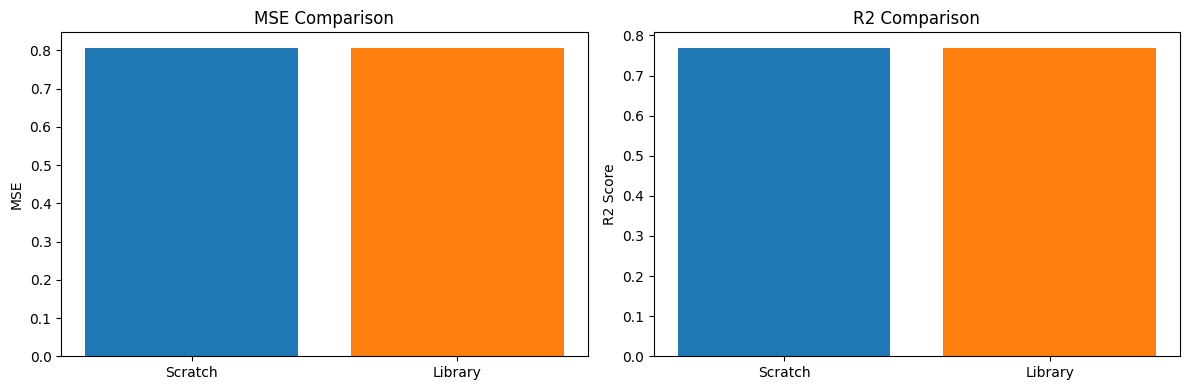

In [29]:
models = ["Scratch", "Library"]
mse_vals = [mse_scratch, mse_lib]
r2_vals = [r2_scratch, r2_lib]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(models, mse_vals, color=["#1f77b4", "#ff7f0e"])
ax[0].set_title("MSE Comparison")
ax[0].set_ylabel("MSE")

ax[1].bar(models, r2_vals, color=["#1f77b4", "#ff7f0e"])
ax[1].set_title("R2 Comparison")
ax[1].set_ylabel("R2 Score")

plt.tight_layout()
plt.show()

## TASK 4: Gradient Descent Based Linear Regression

In [30]:
def train_linear_gd(X, y, lr=0.05, epochs=300, l2_lambda=0.0):
    X_vec = X.reshape(-1)
    y_vec = y.reshape(-1)
    m = len(X_vec)

    w, b = 0.0, 0.0
    loss_history, w_history, b_history = [], [], []

    for _ in range(epochs):
        y_hat = w * X_vec + b
        error = y_hat - y_vec

        dw = (2 / m) * np.dot(error, X_vec) + (2 * l2_lambda / m) * w
        db = (2 / m) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        loss_history.append(np.mean(error ** 2))
        w_history.append(w)
        b_history.append(b)

    return w, b, loss_history, w_history, b_history

In [31]:
w_gd, b_gd, loss_gd, w_hist_gd, b_hist_gd = train_linear_gd(
    X, y, lr=0.05, epochs=300, l2_lambda=0.0
)

y_pred_gd = w_gd * X + b_gd
mse_gd = mean_squared_error(y, y_pred_gd)
r2_gd = r2_score(y, y_pred_gd)

print(f"GD Equation: y = {w_gd:.2f}x + {b_gd:.2f}")
print(f"GD MSE: {mse_gd:.4f}")
print(f"GD R2 : {r2_gd:.4f}")

GD Equation: y = 2.78x + 4.21
GD MSE: 0.8066
GD R2 : 0.7693


## TASK 5: Plot Error vs Iterations (Gradient Descent)

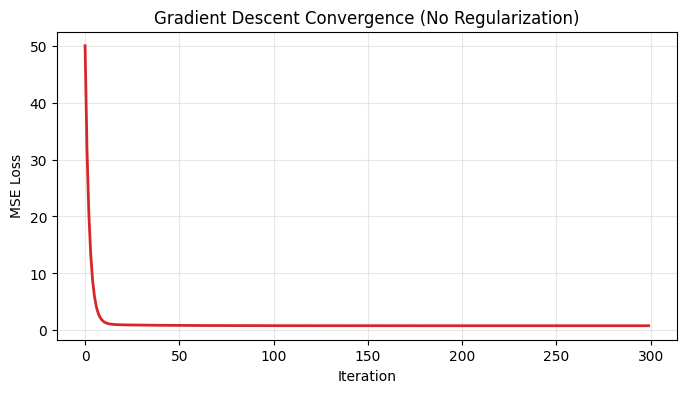

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(loss_gd, color="#d62728", linewidth=2)
plt.title("Gradient Descent Convergence (No Regularization)")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.show()

## TASK 6: Apply L2 Regularization to Gradient Descent

In [33]:
lambda_l2 = 1.0
w_ridge, b_ridge, loss_ridge, w_hist_ridge, b_hist_ridge = train_linear_gd(
    X, y, lr=0.05, epochs=300, l2_lambda=lambda_l2
)

y_pred_ridge = w_ridge * X + b_ridge
mse_ridge = mean_squared_error(y, y_pred_ridge)
r2_ridge = r2_score(y, y_pred_ridge)

print(f"Ridge-GD Equation: y = {w_ridge:.2f}x + {b_ridge:.2f}")
print(f"Ridge-GD MSE: {mse_ridge:.4f}")
print(f"Ridge-GD R2 : {r2_ridge:.4f}")

Ridge-GD Equation: y = 2.70x + 4.28
Ridge-GD MSE: 0.8084
Ridge-GD R2 : 0.7688


## TASK 7: Compare Without vs With Regularization

In [34]:
print("Without Regularization (GD)")
print(f"w = {w_gd:.4f}, b = {b_gd:.4f}, MSE = {mse_gd:.4f}, R2 = {r2_gd:.4f}\n")

print("With L2 Regularization (Ridge-GD)")
print(f"w = {w_ridge:.4f}, b = {b_ridge:.4f}, MSE = {mse_ridge:.4f}, R2 = {r2_ridge:.4f}")

Without Regularization (GD)
w = 2.7753, b = 4.2092, MSE = 0.8066, R2 = 0.7693

With L2 Regularization (Ridge-GD)
w = 2.6982, b = 4.2818, MSE = 0.8084, R2 = 0.7688


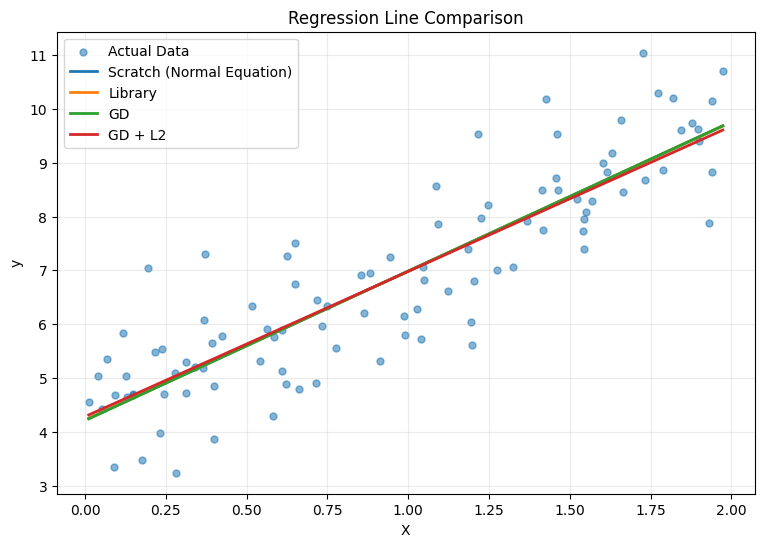

In [35]:
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

plt.figure(figsize=(9, 6))
plt.scatter(X, y, s=25, alpha=0.55, label="Actual Data")
plt.plot(x_line, w * x_line + b, linewidth=2, label="Scratch (Normal Equation)")
plt.plot(x_line, w_lib * x_line + b_lib, linewidth=2, label="Library")
plt.plot(x_line, w_gd * x_line + b_gd, linewidth=2, label="GD")
plt.plot(x_line, w_ridge * x_line + b_ridge, linewidth=2, label="GD + L2")
plt.title("Regression Line Comparison")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## TASK 8: Convergence Behavior and Coefficient Stability Analysis

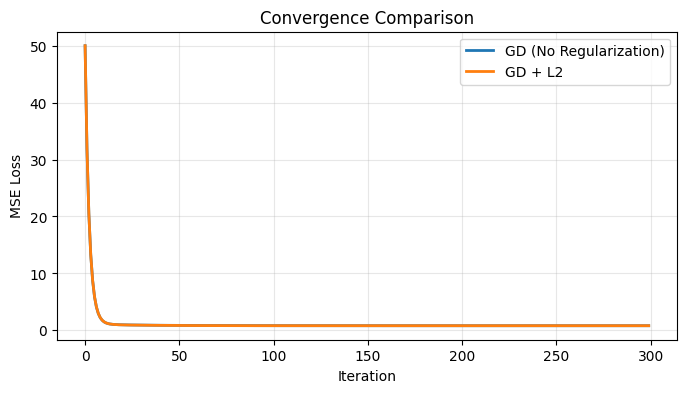

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(loss_gd, label="GD (No Regularization)", linewidth=2)
plt.plot(loss_ridge, label="GD + L2", linewidth=2)
plt.title("Convergence Comparison")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

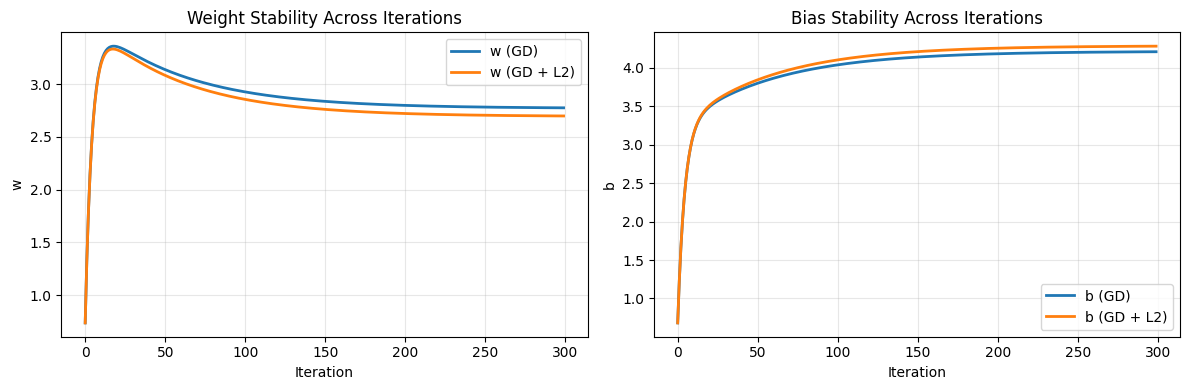

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(w_hist_gd, label="w (GD)", linewidth=2)
ax[0].plot(w_hist_ridge, label="w (GD + L2)", linewidth=2)
ax[0].set_title("Weight Stability Across Iterations")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("w")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(b_hist_gd, label="b (GD)", linewidth=2)
ax[1].plot(b_hist_ridge, label="b (GD + L2)", linewidth=2)
ax[1].set_title("Bias Stability Across Iterations")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("b")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
print("Convergence Analysis")
print(f"Initial GD loss: {loss_gd[0]:.4f} -> Final GD loss: {loss_gd[-1]:.4f}")
print(f"Initial Ridge loss: {loss_ridge[0]:.4f} -> Final Ridge loss: {loss_ridge[-1]:.4f}")

print("\nCoefficient Stability (last 50 iterations)")
print(f"Std of w (GD): {np.std(w_hist_gd[-50:]):.6f}")
print(f"Std of w (Ridge): {np.std(w_hist_ridge[-50:]):.6f}")
print(f"Std of b (GD): {np.std(b_hist_gd[-50:]):.6f}")
print(f"Std of b (Ridge): {np.std(b_hist_ridge[-50:]):.6f}")

print("\nInterpretation:")
print("1) Both methods converge, but L2 gives slightly more controlled coefficient growth.")
print("2) L2 usually trades a tiny increase in training error for better stability.")
print("3) Similar final losses indicate both fit this dataset well.")

Convergence Analysis
Initial GD loss: 50.0083 -> Final GD loss: 0.8066
Initial Ridge loss: 50.0083 -> Final Ridge loss: 0.8084

Coefficient Stability (last 50 iterations)
Std of w (GD): 0.001989
Std of w (Ridge): 0.001963
Std of b (GD): 0.002253
Std of b (Ridge): 0.002234

Interpretation:
1) Both methods converge, but L2 gives slightly more controlled coefficient growth.
2) L2 usually trades a tiny increase in training error for better stability.
3) Similar final losses indicate both fit this dataset well.
